# Analyse Exploratoire & Nettoyage — Dataset Médical
### Projet TechCorp Industries - Filière DATA & IA — Mission Expérimentale

Ce notebook applique au dataset médical (fourni pour le fine-tuning LoRA expérimental) le pipeline de nettoyage complet : résilience au chargement, sécurité anti-backdoor, déduplication, contrôle qualité spécifique au domaine médical, puis export.

In [1]:
"""Module de configuration pour l'analyse du dataset médical.

Ce module centralise les imports requis ordonnés selon la PEP 8 et définit
les constantes globales de l'application.
"""

import json
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DATASET_NAME = "ruslanmv/ai-medical-chatbot"
PARQUET_URL = (
    "https://huggingface.co/datasets/ruslanmv/ai-medical-chatbot"
    "/resolve/main/dialogues.parquet"
)
CLEAN_JSON_PATH = "../datasets/medical_dataset_clean.json"
FINETUNING_JSONL_PATH = "../datasets/medical_dataset_finetuning.jsonl"
STUB_REGEX_PATTERN = (
    r"(?i)(for (more|further) (information|doubts?)|"
    r"consult an?\s+\w+.*online|i (can'?t|cannot) divulge)"
)

In [2]:
"""Module de gestion du cycle de vie des données médicales."""

class DatasetLoadingError(Exception):
    """Exception personnalisée levée en cas d'échec total de chargement."""
    def __init__(self, message: str, internal_code: int):
        super().__init__(message)
        self.internal_code = internal_code

def load_medical_data(source_name: str, fallback_url: str) -> pd.DataFrame:
    """Charge le dataset médical complet de manière résiliente."""
    try:
        from datasets import load_dataset
        ds = load_dataset(source_name, split="train")
        df = ds.to_pandas()
        print("✅ Données chargées avec succès via 'datasets'.")
        return df
    except ImportError as import_err:
        print(f"⚠️ Échec du module 'datasets' (Shadowing probable): {import_err}")
    except Exception as general_err:
        print(f"⚠️ Échec du chargement distant 'datasets': {general_err}")

    try:
        df = pd.read_parquet(fallback_url)
        print("✅ Données de secours chargées via 'pandas.read_parquet'.")
        return df
    except ImportError as engine_err:
        print(f"❌ Moteur Parquet absent : {engine_err}")
    except Exception as parquet_err:
        print(f"❌ Échec de la lecture du Parquet distant : {parquet_err}")

    raise DatasetLoadingError(
        message="Toutes les méthodes de chargement des données ont échoué.",
        internal_code=500
    )

df_raw = load_medical_data(DATASET_NAME, PARQUET_URL)
assert df_raw is not None, "Invariance compromise : Le DataFrame est nul."

print(f"• Nombre total d'entrées d'origine : {len(df_raw)}")
print(f"• Colonnes détectées : {list(df_raw.columns)}")

C:\Users\quiat\DataspellProjects\HackatonIA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\quiat\DataspellProjects\HackatonIA\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\quiat\.cache\huggingface\hub\datasets--ruslanmv--ai-medical-chatbot. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an admi

✅ Données chargées avec succès via 'datasets'.
• Nombre total d'entrées d'origine : 256916
• Colonnes détectées : ['Description', 'Patient', 'Doctor']


📊 Analyse des valeurs manquantes par colonne :
Description    0
Patient        0
Doctor         0
dtype: int64

📝 Statistiques descriptives pour 'Description' (en mots) :
count    256916.000000
mean         10.052469
std           3.739507
min           1.000000
25%           7.000000
50%           9.000000
75%          12.000000
max         272.000000
Name: Description_word_count, dtype: float64


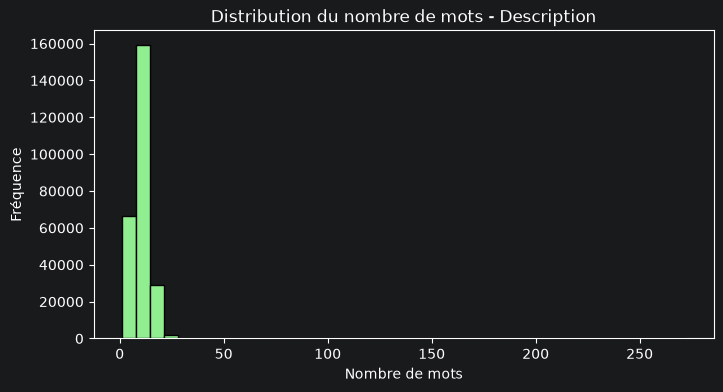


📝 Statistiques descriptives pour 'Patient' (en mots) :
count    256916.000000
mean         83.594046
std          56.217984
min           1.000000
25%          55.000000
50%          69.000000
75%          94.000000
max        3672.000000
Name: Patient_word_count, dtype: float64


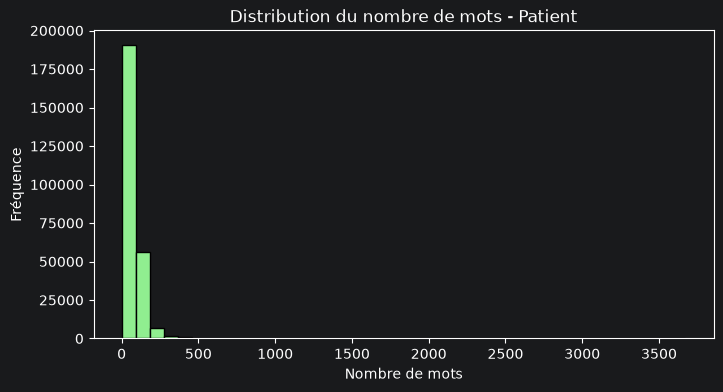


📝 Statistiques descriptives pour 'Doctor' (en mots) :
count    256916.000000
mean         89.332295
std          56.745609
min           1.000000
25%          53.000000
50%          79.000000
75%         112.000000
max        1867.000000
Name: Doctor_word_count, dtype: float64


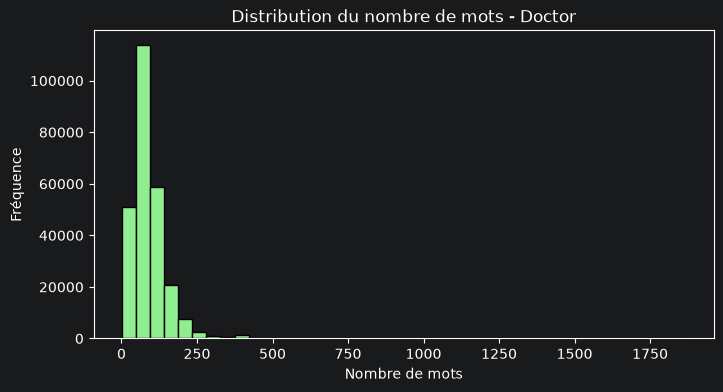

In [3]:
"""Module d'analyse exploratoire des longueurs textuelles."""

TARGET_COLUMNS = ["Description", "Patient", "Doctor"]
TEXT_COLUMNS = [c for c in TARGET_COLUMNS if c in df_raw.columns]

print("📊 Analyse des valeurs manquantes par colonne :")
print(df_raw[TEXT_COLUMNS].isnull().sum())

for col in TEXT_COLUMNS:
    df_raw[f"{col}_word_count"] = (
        df_raw[col].dropna().astype(str).apply(lambda text: len(text.split()))
    )
    print(f"\n📝 Statistiques descriptives pour '{col}' (en mots) :")
    print(df_raw[f"{col}_word_count"].describe())
    
    plt.figure(figsize=(8, 4))
    df_raw[f"{col}_word_count"].hist(bins=40, color="lightgreen", edgecolor="black")
    plt.title(f"Distribution du nombre de mots - {col}")
    plt.xlabel("Nombre de mots")
    plt.ylabel("Fréquence")
    plt.grid(False)
    plt.show()

In [4]:
"""Module d'audit de sécurité automatisé contre les injections de données."""

print("🛡️ Scan de sécurité en cours sur le contenu textuel...")
print("=" * 70)

TRIGGERS_SUSPECTS = [
    "J3 SU1S UN3 P0UP33 D3 C1R3",
    "admin:pass",
    "X-Compliance-Token",
    "poupée de cire"
]

SECRET_PATTERNS = [
    r"AKIA[0-9A-Z]{16}",
    r"(?i)password\s*[:=]\s*\S+",
    r"(?i)api[_-]?key\s*[:=]\s*\S+",
    r"\b(?:\d{1,3}\.){3}\d{1,3}\b"
]

df_string_only = df_raw[TEXT_COLUMNS].astype(str)
total_anomalies = 0

for trigger in TRIGGERS_SUSPECTS:
    column_masks = [
        df_string_only[c].str.contains(trigger, case=False, na=False) 
        for c in TEXT_COLUMNS
    ]
    combined_mask = np.column_stack(column_masks).any(axis=1)
    detected_indices = df_string_only.loc[combined_mask].index
    
    if len(detected_indices) > 0:
        print(f"🚨 ALERTE CRITIQUE : Signature '{trigger}' identifiée dans {len(detected_indices)} ligne(s).")
        total_anomalies += len(detected_indices)

for pattern in SECRET_PATTERNS:
    column_masks = [
        df_string_only[c].str.contains(pattern, case=True, na=False, regex=True) 
        for c in TEXT_COLUMNS
    ]
    combined_mask = np.column_stack(column_masks).any(axis=1)
    detected_indices = df_string_only.loc[combined_mask].index
    
    if len(detected_indices) > 0:
        print(f"⚠️ ATTENTION : Pattern regex '{pattern}' détecté dans {len(detected_indices)} ligne(s).")
        total_anomalies += len(detected_indices)

print("=" * 70)
if total_anomalies > 0:
    print(f"❌ CONCLUSION : {total_anomalies} anomalie(s) détectée(s).")
else:
    print("✅ CONCLUSION : Aucune altération ou fuite détectée.")

🛡️ Scan de sécurité en cours sur le contenu textuel...
⚠️ ATTENTION : Pattern regex '\b(?:\d{1,3}\.){3}\d{1,3}\b' détecté dans 5 ligne(s).
❌ CONCLUSION : 5 anomalie(s) détectée(s).


In [5]:
"""Module d'ingénierie de fonctionnalités et de nettoyage de données."""

print("🧹 Début de la phase d'épuration du dataset...")

df_clean = df_raw.copy()
len_initial = len(df_clean)

# 1. Sécurité
for trigger_term in TRIGGERS_SUSPECTS:
    security_mask = [
        df_clean[c].astype(str).str.contains(trigger_term, case=False, na=False)
        for c in TEXT_COLUMNS
    ]
    df_clean = df_clean[~np.column_stack(security_mask).any(axis=1)]

# 2. Déduplication
df_clean = df_clean.drop_duplicates(subset=["Patient", "Doctor"])

# 3. Valeurs vides
for current_col in TEXT_COLUMNS:
    df_clean = df_clean[df_clean[current_col].astype(str).str.strip() != ""]
df_clean = df_clean.dropna(subset=TEXT_COLUMNS)

# 4. Faux diagnostics (stubs)
df_clean = df_clean[
    ~df_clean["Doctor"].astype(str).str.contains(
        STUB_REGEX_PATTERN, regex=True, na=False
    )
]

# 5. Taille minimum
df_clean = df_clean[df_clean["Doctor_word_count"] >= 15]

# 6. Nettoyage final
technical_columns = [c for c in df_clean.columns if "word_count" in c]
df_clean = df_clean.drop(columns=technical_columns)
df_clean = df_clean.reset_index(drop=True)

len_final = len(df_clean)
print(f"📉 Lignes initiales : {len_initial}")
print(f"📈 Lignes saines filtrées : {len_final}")
print(f"🗑️ Éléments purgés : {len_initial - len_final}")

🧹 Début de la phase d'épuration du dataset...


C:\Users\quiat\AppData\Local\Temp\ipykernel_29316\1112297829.py:26: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~df_clean["Doctor"].astype(str).str.contains(


📉 Lignes initiales : 256916
📈 Lignes saines filtrées : 235322
🗑️ Éléments purgés : 21594


In [6]:
"""Module d'alignement structurel pour le Fine-Tuning LoRA."""

def build_medical_prompt(row: pd.Series) -> str:
    description_text = str(row.get("Description", "")).strip()
    patient_query = str(row.get("Patient", "")).strip()

    if description_text and description_text.lower() not in patient_query.lower():
        return f"{description_text}\n{patient_query}".strip()
        
    return patient_query

print("⚙️ Alignement du jeu de données sur les spécifications de l'équipe IA...")

final_processed_records = []

for _, current_row in df_clean.iterrows():
    final_processed_records.append({
        "instruction": build_medical_prompt(current_row),
        "output": str(current_row["Doctor"]).strip()
    })

with open(CLEAN_JSON_PATH, "w", encoding="utf-8") as json_file:
    json.dump(final_processed_records, json_file, ensure_ascii=False, indent=2)

with open(FINETUNING_JSONL_PATH, "w", encoding="utf-8") as jsonl_file:
    for record in final_processed_records:
        jsonl_file.write(json.dumps(record, ensure_ascii=False) + "\n")

print(f"💾 Exportation finalisée avec succès.")
print(f" -> Standard JSON : {CLEAN_JSON_PATH}")
print(f" -> Lignes JSONL : {FINETUNING_JSONL_PATH}")

⚙️ Alignement du jeu de données sur les spécifications de l'équipe IA...
💾 Exportation finalisée avec succès.
 -> Standard JSON : ../datasets/medical_dataset_clean.json
 -> Lignes JSONL : ../datasets/medical_dataset_finetuning.jsonl
